🧠 Memulai pelatihan 'Smooth & Bold' (120.000 langkah)...
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 100      |
|    ep_rew_mean     | 1.19e+03 |
| time/              |          |
|    fps             | 4811     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 100         |
|    ep_rew_mean          | 992         |
| time/                   |             |
|    fps                  | 3375        |
|    iterations           | 2           |
|    time_elapsed         | 1           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.013033145 |
|    clip_fraction        | 0.224       |
|    

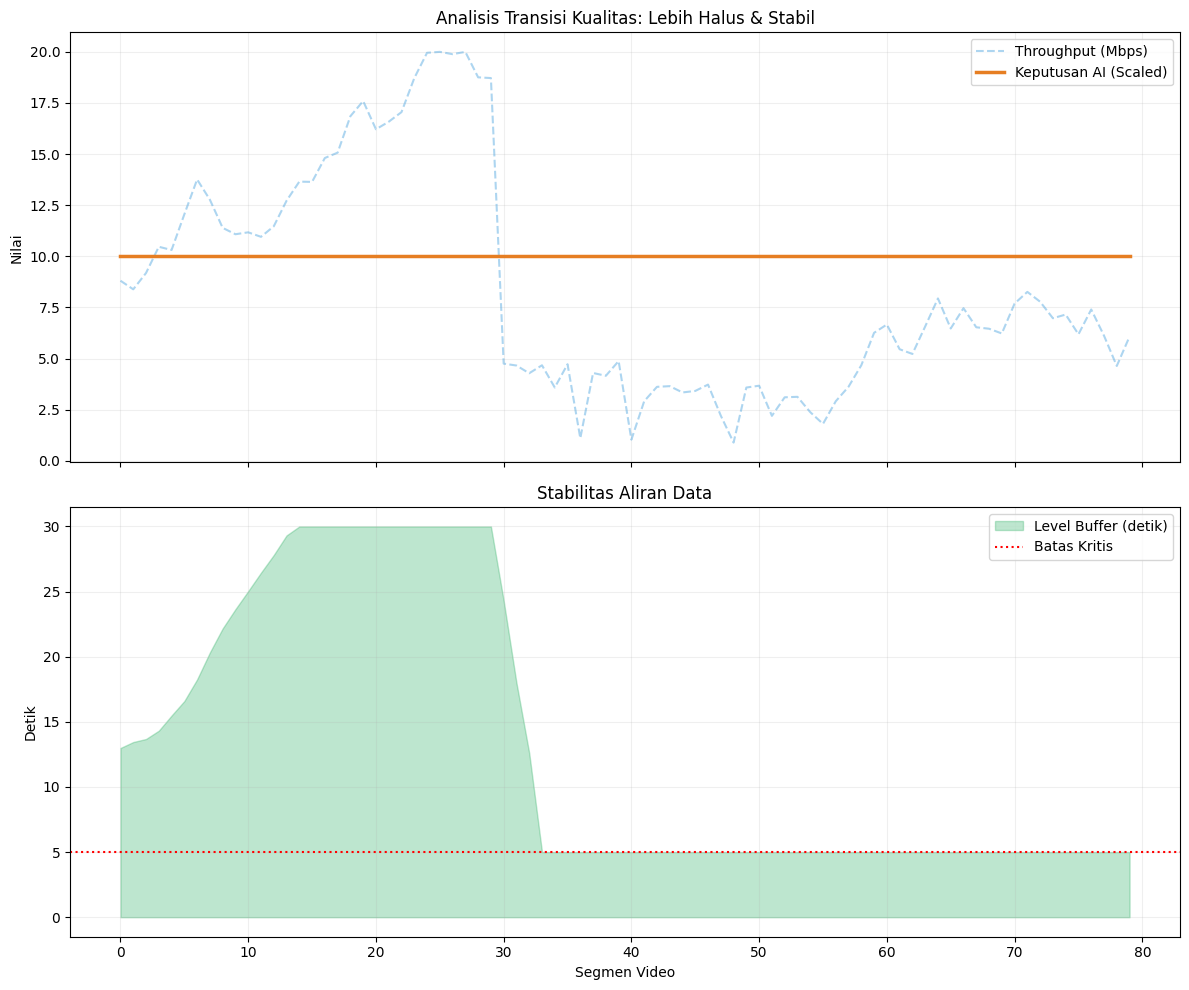

In [2]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
from stable_baselines3 import PPO
import matplotlib.pyplot as plt
import pandas as pd

class BolderShakaEnv(gym.Env):
    """
    Simulator Lingkungan Shaka NDN yang dioptimalkan untuk 
    transisi kualitas yang lebih halus dan cerdas.
    """
    def __init__(self):
        super(BolderShakaEnv, self).__init__()
        
        # Action: 0=Low (0.5), 1=Mid (2.5), 2=High (8.0 Mbps)
        self.action_space = spaces.Discrete(3)
        self.bitrates = [0.5, 2.5, 8.0]

        # Obs: [Buffer, Throughput, LastQual, RTT, Dropped]
        self.observation_space = spaces.Box(
            low=np.array([0, 0, 0, 0, 0]),
            high=np.array([30, 20, 2, 1000, 100]),
            dtype=np.float32
        )

        self.state = None
        self.current_step = 0
        self.max_steps = 100

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.state = np.array([12.0, 10.0, 1.0, 50.0, 0.0], dtype=np.float32)
        self.current_step = 0
        return self.state, {}

    def step(self, action):
        buffer, throughput, last_qual, rtt, dropped = self.state
        chosen_bitrate = self.bitrates[action]
        
        seg_dur = 5.0
        download_time = (chosen_bitrate * seg_dur / (throughput + 0.1)) + (rtt / 1000.0)
        
        stalling = max(0, download_time - buffer)
        new_buffer = max(0, buffer - download_time) + seg_dur
        new_buffer = min(new_buffer, 30.0)

        # --- LOGIKA REWARD YANG DIHALUSKAN (ANTI-KAKU) ---
        
        # 1. Base Reward (Logaritmik agar tidak terlalu biner)
        reward = np.log2(chosen_bitrate + 1) * 10.0

        # 2. Penalti Macet (Tetap yang paling utama)
        if stalling > 0:
            reward -= (stalling * 50.0)
        
        # 3. Switching Penalty (DITINGKATKAN agar tidak kaku/lompat-lompat)
        # Menghukum perubahan kualitas yang terlalu sering
        diff = abs(action - last_qual)
        if diff > 0:
            reward -= (diff * 8.0) # Penalti lebih berat untuk lompatan jauh (Low ke High)

        # 4. Stability Bonus (Mendorong Agen tetap di kualitas yang sama jika aman)
        if action == last_qual and stalling == 0 and new_buffer > 10:
            reward += 2.0

        # 5. Penalti Buffer Kritis
        if new_buffer < 5:
            reward -= 5.0

        # Simulasi Jaringan NDN yang lebih realistis
        new_throughput = np.clip(throughput + np.random.uniform(-1.5, 1.8), 0.5, 20.0)
        new_rtt = np.clip(rtt + np.random.uniform(-15, 15), 10, 500)

        self.state = np.array([new_buffer, new_throughput, float(action), new_rtt, 0.0], dtype=np.float32)
        self.current_step += 1
        done = self.current_step >= self.max_steps
        
        return self.state, reward, done, False, {}

def run_training():
    print("🧠 Memulai pelatihan 'Smooth & Bold' (120.000 langkah)...")
    env = BolderShakaEnv()
    
    # Gunakan PPO dengan entropic coefficient agar lebih banyak eksplorasi di tengah
    model = PPO("MlpPolicy", env, verbose=1, learning_rate=0.00025, ent_coef=0.01)
    model.learn(total_timesteps=120000)
    
    print("📊 Menjalankan Evaluasi Performa...")
    obs, _ = env.reset()
    results = []
    
    for i in range(80):
        # Skenario internet fluktuatif sedang
        if 30 <= i <= 50:
            obs[1] = np.random.uniform(2.0, 4.0) # Internet "Mid"
            
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, _, _ = env.step(action)
        results.append({
            'Langkah': i,
            'Throughput': obs[1],
            'Buffer': obs[0],
            'Kualitas': action
        })

    df = pd.DataFrame(results)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

    ax1.plot(df['Langkah'], df['Throughput'], label='Throughput (Mbps)', color='#3498db', alpha=0.4, linestyle='--')
    ax1.step(df['Langkah'], df['Kualitas'] * 4 + 2, label='Keputusan AI (Scaled)', color='#e67e22', linewidth=2.5)
    ax1.set_title("Analisis Transisi Kualitas: Lebih Halus & Stabil")
    ax1.set_ylabel("Nilai")
    ax1.legend()
    ax1.grid(alpha=0.2)

    ax2.fill_between(df['Langkah'], df['Buffer'], color='#27ae60', alpha=0.3, label='Level Buffer (detik)')
    ax2.axhline(y=5, color='red', linestyle=':', label='Batas Kritis')
    ax2.set_title("Stabilitas Aliran Data")
    ax2.set_ylabel("Detik")
    ax2.set_xlabel("Segmen Video")
    ax2.legend()
    ax2.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_training()